In [1]:
#importing the required libraries for classification using XGBoost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the laon dataset
df = pd.read_csv(r"D:\Three-capstone-projects\loan-approval\dataset\loan_data.csv")

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [6]:
# changing the data type of person_age to integer
df['person_age'] = df['person_age'].astype(int)
df['person_age'].dtype

dtype('int64')

In [7]:
df.shape

(45000, 14)

In [8]:
# check for the missing values
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [9]:
# Check for the duplicated rows
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [11]:
# Saving the numercial attributes
numeric_features = df.select_dtypes(include=['int64', 'float64'])
numeric_features.head(2)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22,71948.0,0,35000.0,16.02,0.49,3.0,561,1
1,21,12282.0,0,1000.0,11.14,0.08,2.0,504,0


In [12]:
# Saving the categorical features
categorical_features = df.select_dtypes(include=['object'])
categorical_features.head(2)

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes


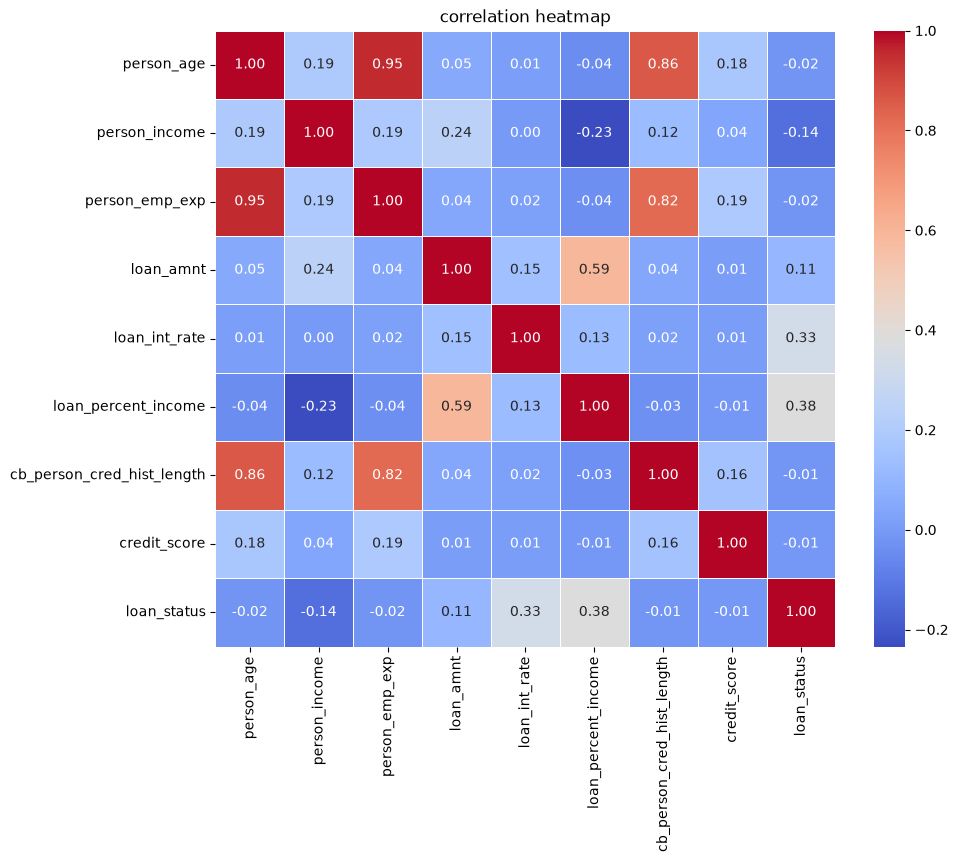

In [13]:
corr = numeric_features.corr()
plt.figure(figsize=(10,8)) # figure size to fit into window
sns.heatmap(corr,annot=True,fmt='0.2f',cmap='coolwarm',linewidths=0.5,)
plt.title("correlation heatmap")
plt.show()

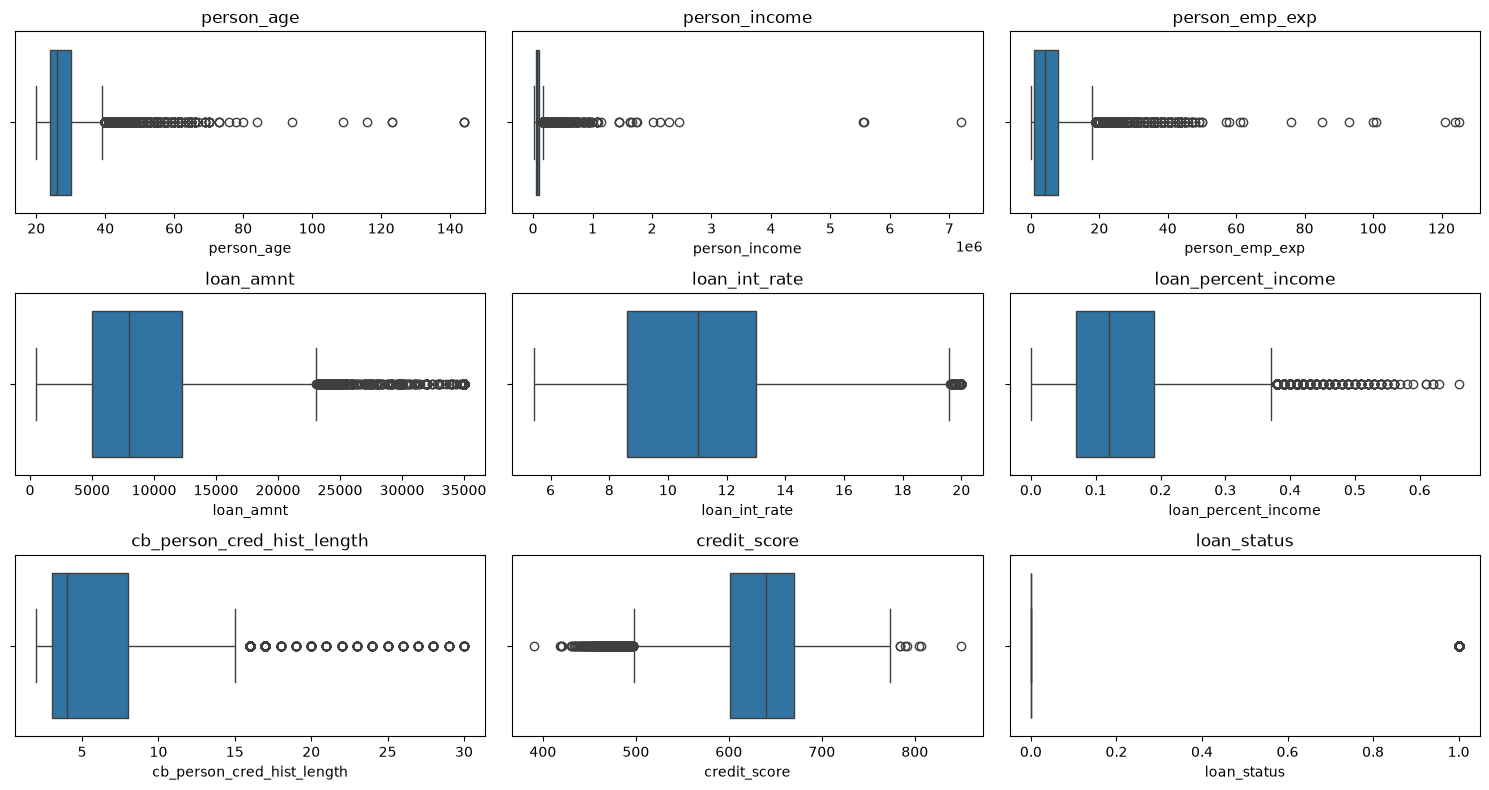

In [14]:
# Analyzing the numerical features by using box plot
plt.figure(figsize=(15,8))
for i ,col in enumerate(numeric_features):
    plt.subplot(3,3,i+1) # i+1 to start index from 1
    sns.boxplot(data=df,x=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [15]:
# Outlier have been found in numerical features
# truncuate the rows have age more than 100 and experice more than 60 years
df = df[(df['person_age'] <= 100) & (df['person_emp_exp'] <= 60)]


In [16]:
# Now for rest of numeric features as per percentile = 99%
num_cols = numeric_features.columns
PERCENTILE = 0.99
for col in num_cols.drop(['person_age', 'person_emp_exp', 'loan_percent_income', 'credit_score']): #drop the rows w.r.to 99% quantile
    upper_limit = df[col].quantile(PERCENTILE)
    df = df[df[col] <= upper_limit]

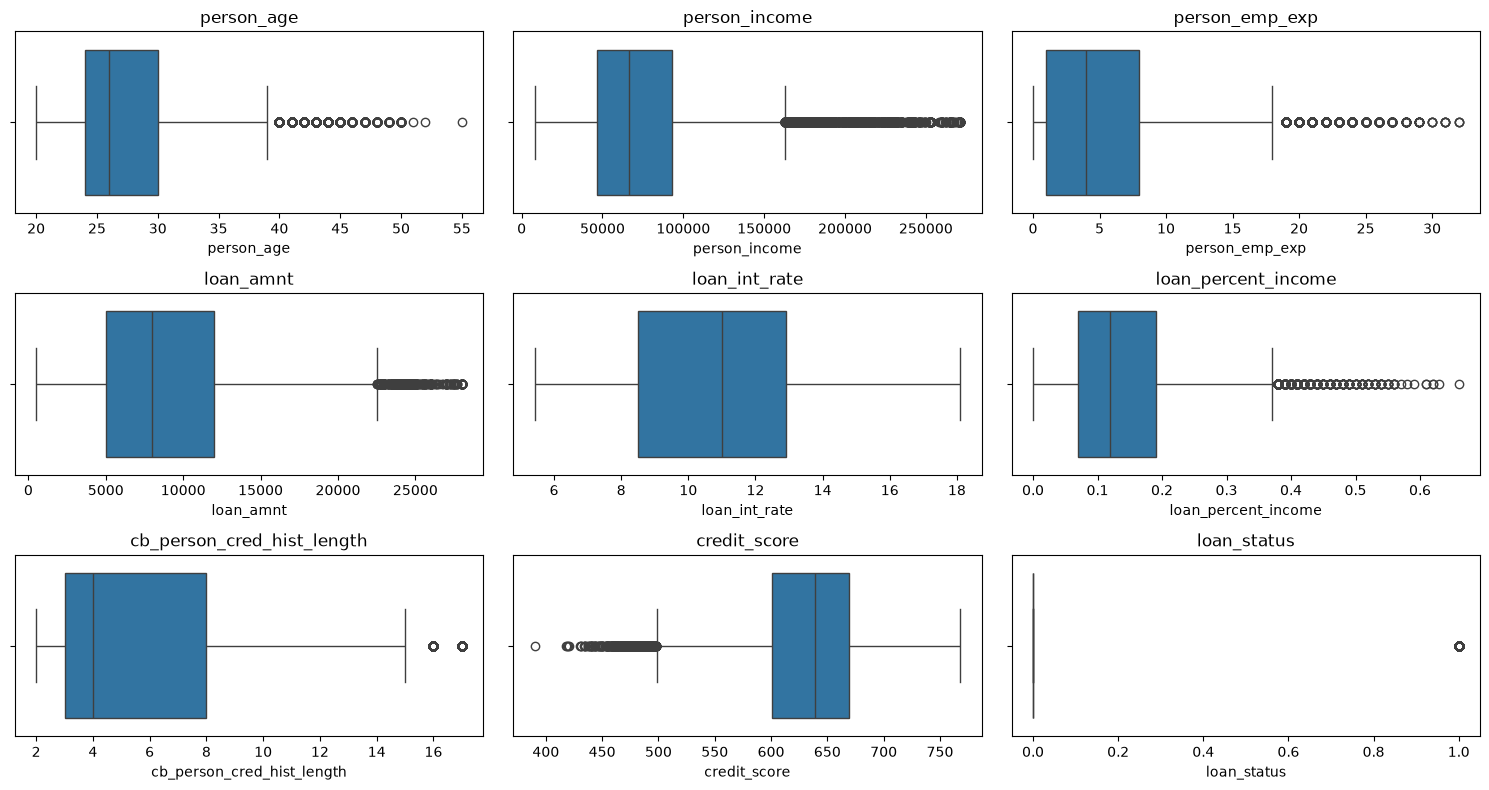

In [17]:
plt.figure(figsize=(15,8))
for i ,col in enumerate(numeric_features):
    plt.subplot(3,3,i+1) # i+1 to start index from 1
    sns.boxplot(data=df,x=col)
    plt.title(col)
plt.tight_layout()
plt.show()

In [18]:
df.shape

(43370, 14)

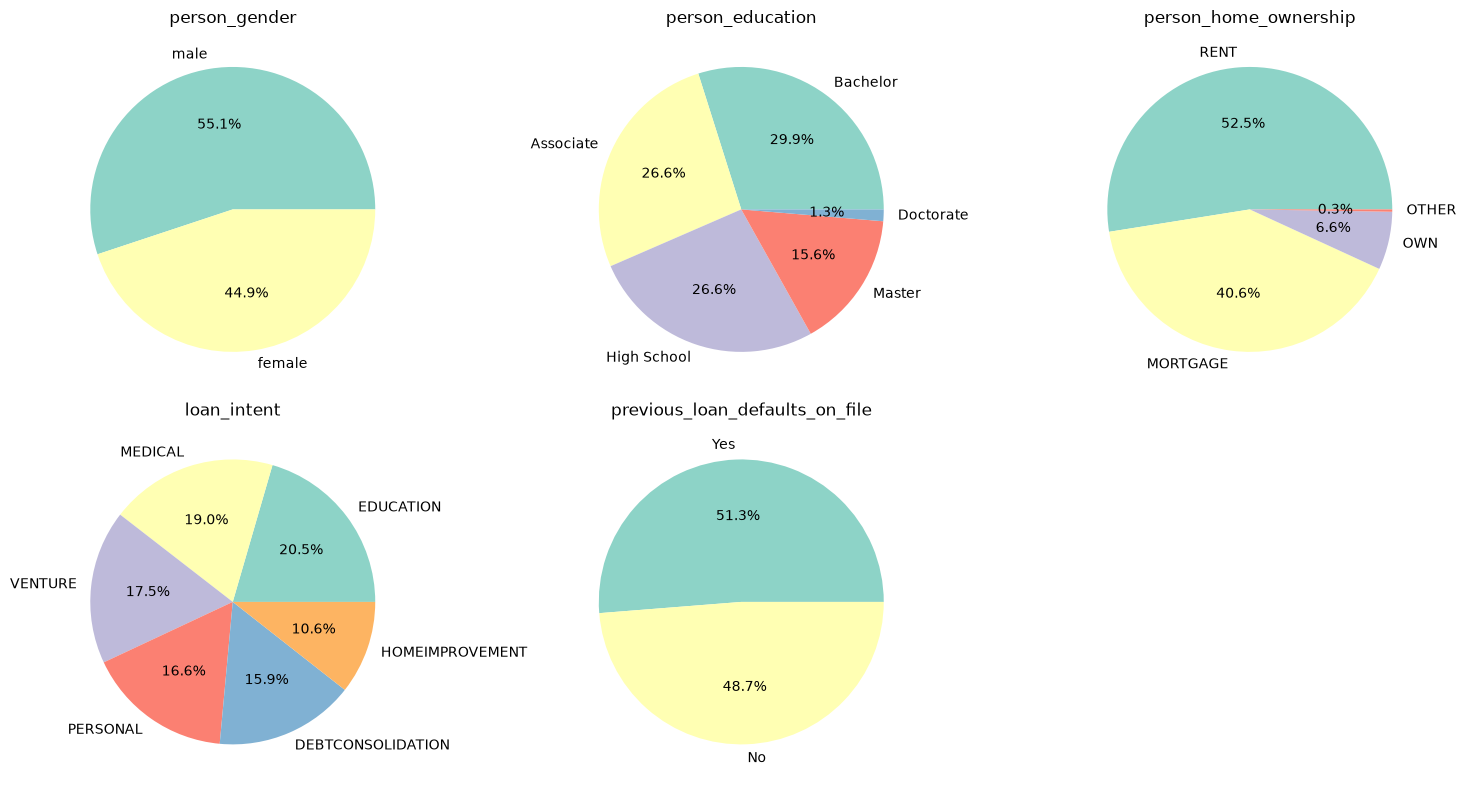

In [19]:
# visualizing the categorical variables on pie chat
plt.figure(figsize=(15,8))
for i, col in enumerate(categorical_features.columns, start=1):
    plt.subplot(2, 3, i)
    counts = df[col].value_counts()
    # setting pie chart prperties
    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=plt.cm.Set3.colors
    )
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
# get unique values for each categorical feature
df_cat = df.select_dtypes('object')

for col in df_cat.columns:
    print(f"{col} => {df[col].unique()}")

person_gender => <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
person_education => <ArrowStringArray>
['High School', 'Associate', 'Master', 'Bachelor', 'Doctorate']
Length: 5, dtype: str
person_home_ownership => <ArrowStringArray>
['OWN', 'MORTGAGE', 'OTHER', 'RENT']
Length: 4, dtype: str
loan_intent => <ArrowStringArray>
[        'EDUCATION',           'MEDICAL',           'VENTURE',
   'HOMEIMPROVEMENT',          'PERSONAL', 'DEBTCONSOLIDATION']
Length: 6, dtype: str
previous_loan_defaults_on_file => <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [21]:
# Seprate the features and target variables
X = df.drop('loan_status',axis=1)
y = df['loan_status']

In [22]:
# seprtating the categorical features and saving in the list format
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [23]:
# Splitting the dataset into X test and y train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# defining preprocessor pipline to use columntransformer production standard
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"), # encoding using onhotencoder for categorical variables of training data
            categorical_cols
        )
    ],
    remainder="passthrough" # plan to use XGBclassifier which does not require scaling of numerical variables
)

In [25]:
# Using XGBcalssifier to catch complex patterns in the dataset
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [26]:
# combining the preprocessor and defined model into the pipline
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [27]:
# model training
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['person_age','person_gender','person_education',..., 'cb_person_cred_hist_length','credit_score', 'previous_loan_defaults_on_file']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [28]:
# Making predictions using tranined model
y_pred = pipeline.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the trained model using XGBClassifier is {accuracy * 100:.2f}%")

Accuracy of the trained model using XGBClassifier is 93.94%


In [30]:
target_names = ['Rejected','Approved']
result = classification_report(y_test, y_pred,target_names=target_names)
print(result)

              precision    recall  f1-score   support

    Rejected       0.95      0.98      0.96      6796
    Approved       0.91      0.80      0.85      1878

    accuracy                           0.94      8674
   macro avg       0.93      0.89      0.91      8674
weighted avg       0.94      0.94      0.94      8674



In [31]:
# dumping model using joblib
joblib.dump(pipeline, 'loan_approval_model.joblib')

['loan_approval_model.joblib']